# LDA
* Vectorization with BoW
* LDA algorithm
* Evaluation with perplexity and coherence
* Visualization with PCA & UMAP <br>
--> Present topic clusters and top words for optimal k

In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import CountVectorizer

from sklearn.decomposition import LatentDirichletAllocation
from gensim.models import CoherenceModel
from gensim import corpora
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.decomposition import PCA
import umap.umap_ as umap
from sklearn.preprocessing import normalize

import pyLDAvis
import pyLDAvis.lda_model

In [2]:
df = pd.read_pickle("data/preprocessed_data.pkl")
df.head(5)

,id,author,question,link_flair_css_class,link_flair_text,description,created_utc,year,retrieved_on,org_post,language,clean_question,clean_desc,question_tokens,desc_tokens,q_tuple,d_tuple,post_tokens
0,421zyl,[deleted],How is time defined at the big bang?,physics,Physics,[removed],2016-01-21 20:58:09,2016,2016-02-09 12:21:05,How is time defined at the big bang? [removed],en,how is time defined at the big bang,removed,"[time, define, big, bang]",[],"(time, define, big, bang)",(),"[time, define, big, bang]"
1,4r857d,[deleted],UFO best scientific explanation. Atmospherical...,geo,Earth Sciences,[removed],2016-07-04 17:05:51,2016,2016-09-03 18:04:14,UFO best scientific explanation. Atmospherical...,en,ufo best scientific explanation atmospherical ...,removed,"[ufo, good, scientific, explanation, atmospher...",[],"(ufo, good, scientific, explanation, atmospher...",(),"[ufo, good, scientific, explanation, atmospher..."
2,4r0zwj,De_La_Soul_,It's a commonly known fact that metals oxidize...,chem,Chemistry,,2016-07-03 06:40:06,2016,2016-09-02 17:31:58,It's a commonly known fact that metals oxidize...,en,it s a commonly known fact that metals oxidize...,,"[commonly, know, fact, metal, oxidize, possibl...",[],"(commonly, know, fact, metal, oxidize, possibl...",(),"[commonly, know, fact, metal, oxidize, possibl..."
3,540ohz,MacShakeIt,"China builds large telescope, but i have a que...",astro,Astronomy,[removed],2016-09-22 19:17:55,2016,2016-10-14 11:02:04,"China builds large telescope, but i have a que...",en,china builds large telescope but i have a ques...,removed,"[china, build, large, telescope, question]",[],"(china, build, large, telescope, question)",(),"[china, build, large, telescope, question]"
4,4r191k,[deleted],Geoscientists: Is there any current research i...,geo,Planetary Sci.,[removed],2016-07-03 08:26:38,2016,2016-09-02 17:34:09,Geoscientists: Is there any current research i...,en,geoscientists is there any current research in...,removed,"[geoscientist, current, research, project, sho...",[],"(geoscientist, current, research, project, sho...",(),"[geoscientist, current, research, project, sho..."


In [ ]:
from gensim.models.phrases import Phrases, Phraser
from sklearn.feature_extraction.text import CountVectorizer

# Load tokens
tokenized_docs = df["post_tokens"].tolist()

# Detect and apply bigrams
phrases = Phrases(tokenized_docs, min_count=5, threshold=10)
bigram = Phraser(phrases)
merged_docs = [bigram[doc] for doc in tokenized_docs]

# Join tokens for vectorization
merged_texts = [" ".join(doc) for doc in merged_docs]

# Vectorization (BoW)
vectorizer = CountVectorizer(
    max_features=10000,
    min_df=5,
    max_df=0.8,
    ngram_range=(1, 1)
)
X = vectorizer.fit_transform(merged_texts)

# Vocabulary size
print(len(vectorizer.vocabulary_))
# Feature names
print(vectorizer.get_feature_names_out())
# Sparse feature matrix
print(X)

10000
['00' '001' '00_00' ... 'zoology' 'zoom' 'zygote']
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3607068 stored elements and shape (590938, 10000)>
  Coords	Values
  (0, 9134)	1
  (0, 2433)	1
  (0, 1024)	1
  (1, 9370)	1
  (1, 4045)	1
  (1, 7892)	1
  (1, 3234)	1
  (1, 5705)	1
  (2, 1872)	1
  (2, 5101)	1
  (2, 3411)	1
  (2, 5695)	1
  (2, 6450)	1
  (2, 6919)	1
  (2, 3887)	1
  (3, 1646)	1
  (3, 1310)	1
  (3, 5144)	1
  (3, 8982)	1
  (3, 7264)	1
  (4, 2291)	1
  (4, 7599)	1
  (4, 5066)	1
  (4, 5780)	1
  (4, 3028)	1
  :	:
  (590933, 7264)	1
  (590933, 9572)	1
  (590933, 7692)	1
  (590933, 3977)	1
  (590933, 7022)	1
  (590933, 607)	1
  (590933, 407)	1
  (590933, 2479)	2
  (590933, 5911)	1
  (590933, 383)	1
  (590934, 3262)	1
  (590934, 1985)	1
  (590935, 9134)	1
  (590935, 2783)	1
  (590936, 3387)	1
  (590936, 5297)	1
  (590936, 237)	1
  (590936, 6495)	1
  (590936, 1705)	1
  (590936, 4416)	1
  (590936, 9226)	1
  (590937, 2899)	1
  (590937, 7993)	1
  (590937, 6737)	1
  (59093

## LDA

### Finding the Best Value for *k*

In [4]:
dictionary = corpora.Dictionary(tokenized_docs)

def train_lda(k, X):
    lda = LatentDirichletAllocation(
        n_components=k,
        learning_method="online",
        max_iter=10,
        random_state=42,
        n_jobs=-1,
        batch_size=8192,
        evaluate_every=-1
    )
    lda.fit(X)
    return lda

In [5]:
def evaluate_model(lda, X, vectorizer, texts, dictionary, top_n=10):

    # Perplexity
    perplexity = lda.perplexity(X)

    # Extract topics
    feature_names = np.array(vectorizer.get_feature_names_out())

    topics = []

    for topic in lda.components_:
        top_words = feature_names[topic.argsort()[-top_n:]]
        topics.append(list(top_words))

    # Coherence
    cm = CoherenceModel(
        topics=topics,
        texts=texts,
        dictionary=dictionary,
        coherence="c_v"
    )

    coherence = cm.get_coherence()

    # Topic diversity
    all_topic_words = []

    for topic in topics:
        all_topic_words.extend(topic)

    diversity = len(set(all_topic_words)) / len(all_topic_words)

    return coherence, perplexity, diversity

In [ ]:
# Broad range for k to find reasonable range
k_values = range(5, 61, 5)

results = []

for k in k_values:
    print(f"Training LDA with k={k}")

    lda = train_lda(k, X)

    coherence, perplexity, diversity = evaluate_model(
    lda, X, vectorizer, tokenized_docs, dictionary
    )

    results.append((k, coherence, perplexity, diversity))

Training LDA with k=5
Training LDA with k=10
Training LDA with k=15
Training LDA with k=20
Training LDA with k=25
Training LDA with k=30
Training LDA with k=35
Training LDA with k=40
Training LDA with k=45
Training LDA with k=50
Training LDA with k=55
Training LDA with k=60


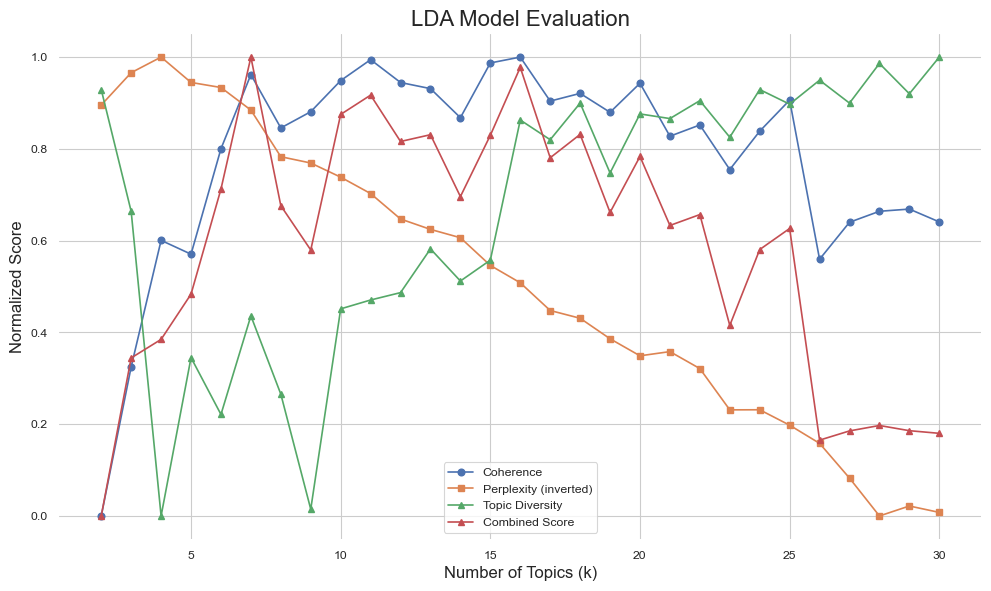

In [20]:
sns.set_theme(style='whitegrid', context='paper')

k_vals = [r[0] for r in results]

coherence = np.array([r[1] for r in results]).reshape(-1, 1)
perplexity = np.array([r[2] for r in results]).reshape(-1, 1)
diversity = np.array([r[3] for r in results]).reshape(-1, 1)

scaler = MinMaxScaler()

coherence_norm = scaler.fit_transform(coherence).flatten()
perplexity_norm = 1 - scaler.fit_transform(perplexity).flatten()    # Invert perplexity (lower score is better)
diversity_norm = scaler.fit_transform(diversity).flatten()

# Calculate combined score
coherence_weight = 0.5
perplexity_weight = 0.3
diversity_weight = 0.2
wide_combined = (
    coherence_weight * coherence_norm +
    perplexity_weight * perplexity_norm +
    diversity_weight * diversity_norm
)

combined_norm = scaler.fit_transform(wide_combined.reshape(-1, 1)).flatten()

plt.figure(figsize=(10,6))

# Despine plot
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['left'].set_visible(False)

plt.plot(
    k_vals,
    coherence_norm,
    marker='o',
    label='Coherence'
)

plt.plot(
    k_vals,
    perplexity_norm,
    marker='s',
    label='Perplexity (inverted)'
)

plt.plot(
    k_vals,
    diversity_norm,
    marker='^',
    label='Topic Diversity'
)

plt.plot(
    k_vals,
    combined_norm,
    marker='^',
    label='Combined Score'
)

plt.xlabel("Number of Topics (k)", fontsize=12)
plt.ylabel("Normalized Score", fontsize=12)
plt.title("LDA Model Evaluation", fontsize=16)

plt.legend()
plt.grid(visible=True)

plt.tight_layout()

plt.savefig('viz/LDA_evaluation_metrics_5-100-5.png', dpi=300)

plt.show()

From the broad overview two relevant areas can be identified. The inverted perplexity score stays relatively constant until k=55 and drops afterwards indicating that *k* should be *< 55*. The coherence score drops sharply right in the beginning and shows two smaller spikes at *k = 30* and *k = 60*. A higher coherence score is desirable for sematically meaniful topics which seems to be quite difficult here. As an additional metric topic diversity was plotted to measure the disctincness of topics. Unlike the coeherence score it rises rapidly with increasing *k* until its peak at *k = 50*. A good tradeoff between coherence and diversity seems to be in the range *k = 5* to *k = 35* which will be investigated with smaller steps in the following.

In [8]:
# Narrow range for k to find the best k
k_values = range(2, 31, 1)

results = []

for k in k_values:
    print(f"Training LDA with k={k}")

    lda = train_lda(k, X)

    coherence, perplexity, diversity = evaluate_model(
    lda, X, vectorizer, tokenized_docs, dictionary
    )

    results.append((k, coherence, perplexity, diversity))

k_vals = [r[0] for r in results]

Training LDA with k=2
Training LDA with k=3
Training LDA with k=4
Training LDA with k=5
Training LDA with k=6
Training LDA with k=7
Training LDA with k=8
Training LDA with k=9
Training LDA with k=10
Training LDA with k=11
Training LDA with k=12
Training LDA with k=13
Training LDA with k=14
Training LDA with k=15
Training LDA with k=16
Training LDA with k=17
Training LDA with k=18
Training LDA with k=19
Training LDA with k=20
Training LDA with k=21
Training LDA with k=22
Training LDA with k=23
Training LDA with k=24
Training LDA with k=25
Training LDA with k=26
Training LDA with k=27
Training LDA with k=28
Training LDA with k=29
Training LDA with k=30


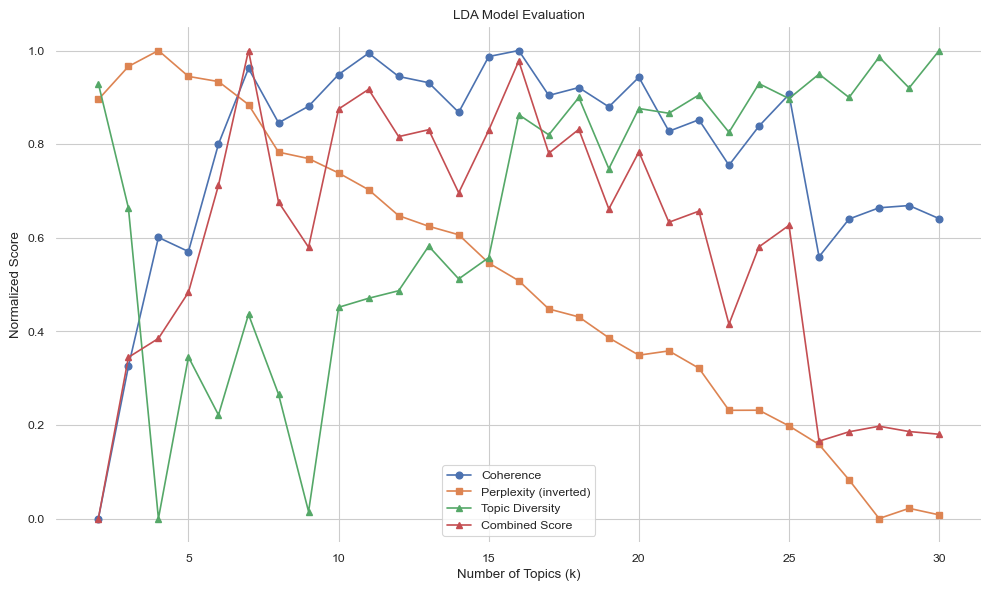

In [ ]:
coherence = np.array([r[1] for r in results]).reshape(-1, 1)
perplexity = np.array([r[2] for r in results]).reshape(-1, 1)
diversity = np.array([r[3] for r in results]).reshape(-1, 1)

scaler = MinMaxScaler()

coherence_norm = scaler.fit_transform(coherence).flatten()
# Invert perplexity (lower score is better)
perplexity_norm = 1 - scaler.fit_transform(perplexity).flatten()
diversity_norm = scaler.fit_transform(diversity).flatten()

# Calculate combined score
coherence_weight = 0.5
perplexity_weight = 0.3
diversity_weight = 0.2
wide_combined = (
    coherence_weight * coherence_norm +
    perplexity_weight * perplexity_norm +
    diversity_weight * diversity_norm
)

combined_norm = scaler.fit_transform(wide_combined.reshape(-1, 1)).flatten()

plt.figure(figsize=(10, 6))

plt.plot(
    k_vals,
    coherence_norm,
    marker='o',
    label='Coherence'
)

plt.plot(
    k_vals,
    perplexity_norm,
    marker='s',
    label='Perplexity (inverted)'
)

plt.plot(
    k_vals,
    diversity_norm,
    marker='^',
    label='Topic Diversity'
)

plt.plot(
    k_vals,
    combined_norm,
    marker='^',
    label='Combined Score'
)

plt.xlabel("Number of Topics (k)")
plt.ylabel("Normalized Score")
plt.title("LDA Model Evaluation")

plt.legend()
plt.grid(visible=True)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['left'].set_visible(False)

plt.tight_layout()

plt.savefig('viz/LDA_evaluation_metrics-2-40-1.png', dpi=300)

plt.show()

### Final Run with Best Values for *k*

In [10]:
def show_topics(model, vectorizer, n_words=20):
    words = vectorizer.get_feature_names_out()

    for i, topic in enumerate(model.components_):
        top_words = [words[j] for j in topic.argsort()[-n_words:]]
        print(f"Topic {i}: {top_words}")

In [11]:
def plot_2D_projection(lda, X, k):

    # Document-topic matrix
    doc_topics = lda.transform(X).astype("float32")

    # Remove weak memberships
    doc_topics[doc_topics < 0.05] = 0

    # Renormalize
    doc_topics = normalize(doc_topics, norm='l1')

    # Dominant topic
    dominant_topic = doc_topics.argmax(axis=1)
    num_topics = doc_topics.shape[1]

    # Colors based on dominant topic
    cmap = plt.colormaps.get_cmap('tab20')
    topic_colors = [cmap(t % 20) for t in dominant_topic]

    sns.set_theme(style='whitegrid', context='paper')
    spine_color = '#cccccc'

    # PCA
    pca = PCA(n_components=2, svd_solver='randomized', random_state=42)
    W_pca = pca.fit_transform(doc_topics)

    # Denoise with PCA
    # doc_topics = PCA(n_components=10).fit_transform(doc_topics)

    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=15,
        min_dist=0.5,
        metric='euclidean',
        n_jobs=-1
    )

    W_umap = reducer.fit_transform(doc_topics)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    titles = ["PCA Projection", "UMAP Projection"]

    for ax, emb, title in zip(axes, [W_pca, W_umap], titles):
        ax.scatter(
            emb[:, 0], emb[:, 1],
            c=topic_colors,
            s=6,
            alpha=0.6
        )

        ax.set_title(f"{title} of LDA Topic Space (k={k})", fontsize=15)
        ax.set_xlabel("Component 1")
        ax.set_ylabel("Component 2")
        ax.grid(alpha=0.3)

        for spine in ax.spines.values():
            spine.set_color(spine_color)

    # Legend
    legend_elements = [
        Line2D(
            [0], [0],
            marker='o', color='w',
            markerfacecolor=cmap(t % 20),
            markersize=8,
            label=f"Topic {t}"
        )
        for t in range(num_topics)
    ]

    axes[1].legend(
        handles=legend_elements,
        title="Topics",
        bbox_to_anchor=(1.05, 1),
        loc='upper left',
        frameon=False
    )

    plt.tight_layout()

    plt.savefig(f'viz/LDA_pca_vs_umap_k{k}.png', dpi=300)

    plt.show()

In [12]:
def get_topic_labels(model, vectorizer, n_words=5):
    words = vectorizer.get_feature_names_out()
    
    labels = {}

    for i, topic in enumerate(model.components_):
        top_words = [words[j] for j in topic.argsort()[-n_words:][::-1]]
        labels[i] = " | ".join(top_words)

    return labels

In [29]:
k = 7

lda = train_lda(k, X)

doc_topics = lda.transform(X)

df["topic"] = doc_topics.argmax(axis=1)
df["topic_prob"] = doc_topics.max(axis=1)

topic_labels = get_topic_labels(lda, vectorizer)

df["topic_label"] = df["topic"].map(topic_labels)

show_topics(lda, vectorizer)

# Viz
viz = pyLDAvis.lda_model.prepare(lda, X, vectorizer)

pyLDAvis.display(viz)

Topic 0: ['produce', 'memory', 'age', 'control', 'know', 'process', 'person', 'way', 'different', 'create', 'power', 'like', 'hear', 'time', 'use', 'energy', 'sound', 'possible', 'work', 'brain']
Topic 1: ['time', 'hard', 'don', 'hair', 'come', 'hand', 'long', 'bad', 'day', 'smell', 'thing', 'light', 'look', 'sleep', 'cause', 'happen', 'eye', 'like', 'feel', 'people']
Topic 2: ['oxygen', 'possible', 'need', 'pressure', 'like', 'liquid', 'high', 'ocean', 'gas', 'hot', 'happen', 'drink', 'cold', 'color', 'body', 'air', 'food', 'heat', 'temperature', 'water']
Topic 3: ['like', 'energy', 'fast', 'star', 'travel', 'mass', 'moon', 'speed', 'possible', 'gravity', 'black_hole', 'sun', 'object', 'universe', 'happen', 'planet', 'time', 'space', 'light', 'earth']
Topic 4: ['get', 'death', 'drug', 'happen', 'cancer', 'climate_change', 'disease', 'increase', 'person', 'affect', 'people', 'virus', '19', 'cell', 'vaccine', 'life', 'cause', 'effect', 'covid', 'body']
Topic 5: ['people', 'real', 'under

In [30]:
k = 16

lda = train_lda(k, X)

doc_topics = lda.transform(X)

df["topic"] = doc_topics.argmax(axis=1)
df["topic_prob"] = doc_topics.max(axis=1)

topic_labels = get_topic_labels(lda, vectorizer)

df["topic_label"] = df["topic"].map(topic_labels)

show_topics(lda, vectorizer)

# Viz
viz = pyLDAvis.lda_model.prepare(lda, X, vectorizer)

pyLDAvis.display(viz)

Topic 0: ['bear', 'change', 'parent', 'mammal', 'chance', 'male', 'live', 'gene', 'chemical', 'know', 'average', 'child', 'evolution', 'different', 'like', 'number', 'evolve', 'specie', 'animal', 'human']
Topic 1: ['height', 'image', 'creature', 'come', 'range', 'play', 'music', 'jump', 'room', 'frequency', 'old', 'cause', 'like', 'wave', 'high', 'death', 'fall', 'climate_change', 'hear', 'sound']
Topic 2: ['like', 'oil', 'dark', 'colour', 'different', 'mirror', 'glass', 'red', 'blue', 'appear', 'see', 'absorb', 'white', 'black', 'plant', 'turn', 'color', 'look', 'eye', 'light']
Topic 3: ['like', 'galaxy', 'matter', 'big_bang', 'fire', 'time', 'shape', 'know', 'size', 'large', 'happen', 'point', 'force', 'mass', 'small', 'gravity', 'object', 'black_hole', 'space', 'universe']
Topic 4: ['process', 'early', 'use', 'datum', 'discover', 'research', 'call', 'brain', 'drug', 'environment', 'long_term', 'real', 'memory', 'evidence', 'experiment', 'impact', 'affect', 'information', 'study', 'e

## Plot Results

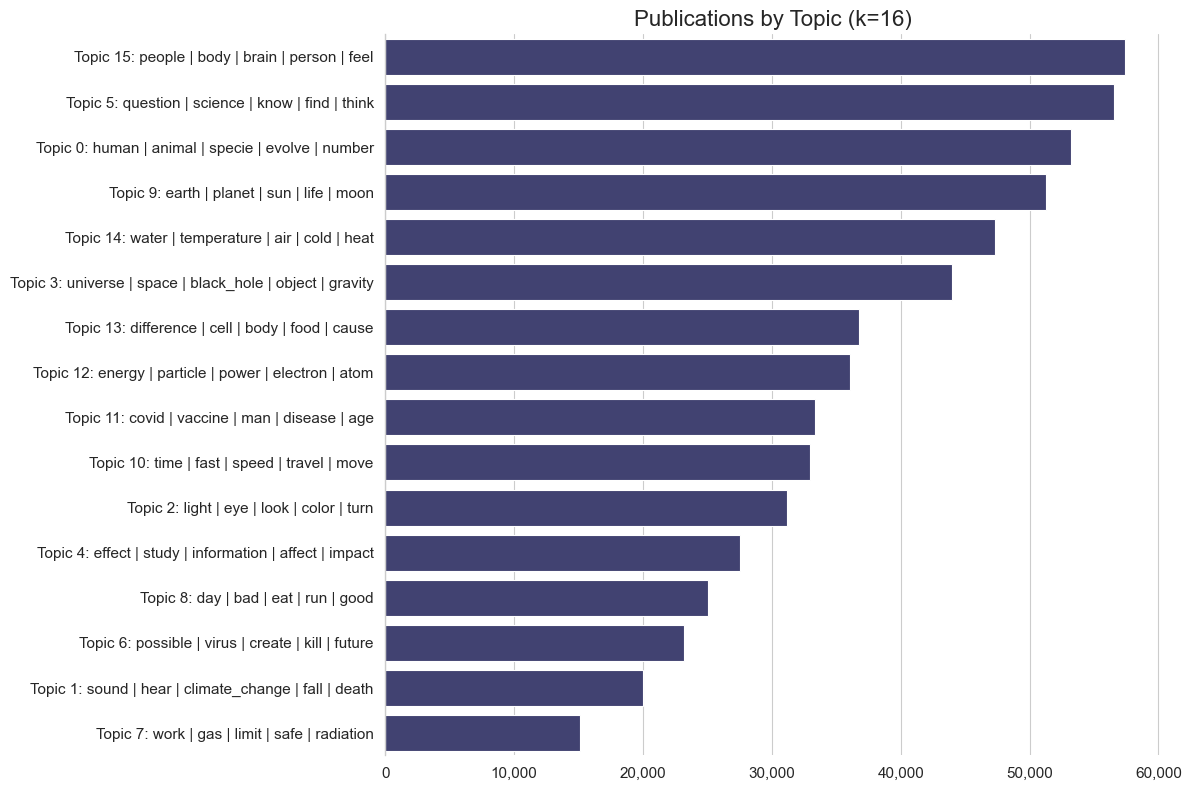

In [31]:
words = vectorizer.get_feature_names_out()

topic_labels = {}

for i, topic in enumerate(lda.components_):
    top_words = [words[j] for j in topic.argsort()[-5:][::-1]]
    topic_labels[i] = f"Topic {i}: " + " | ".join(top_words)

df["topic_label"] = df["topic"].map(topic_labels)

color = plt.colormaps["tab20b"](0)

fig, ax = plt.subplots(figsize=(12, 8))

sns.countplot(
    data=df,
    y="topic_label",
    order=df["topic_label"].value_counts().index,
    ax=ax,
    color=color
)

ax.set_title(f"Publications by Topic (k={k})", fontsize=16)
ax.set_xlabel("")
ax.set_ylabel("")

ax.tick_params(axis='y', labelsize=11)
ax.tick_params(axis='x', labelsize=11)

ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.savefig(f"viz/LDA_posts_per_topic_k{k}.png", dpi=300)
plt.show()

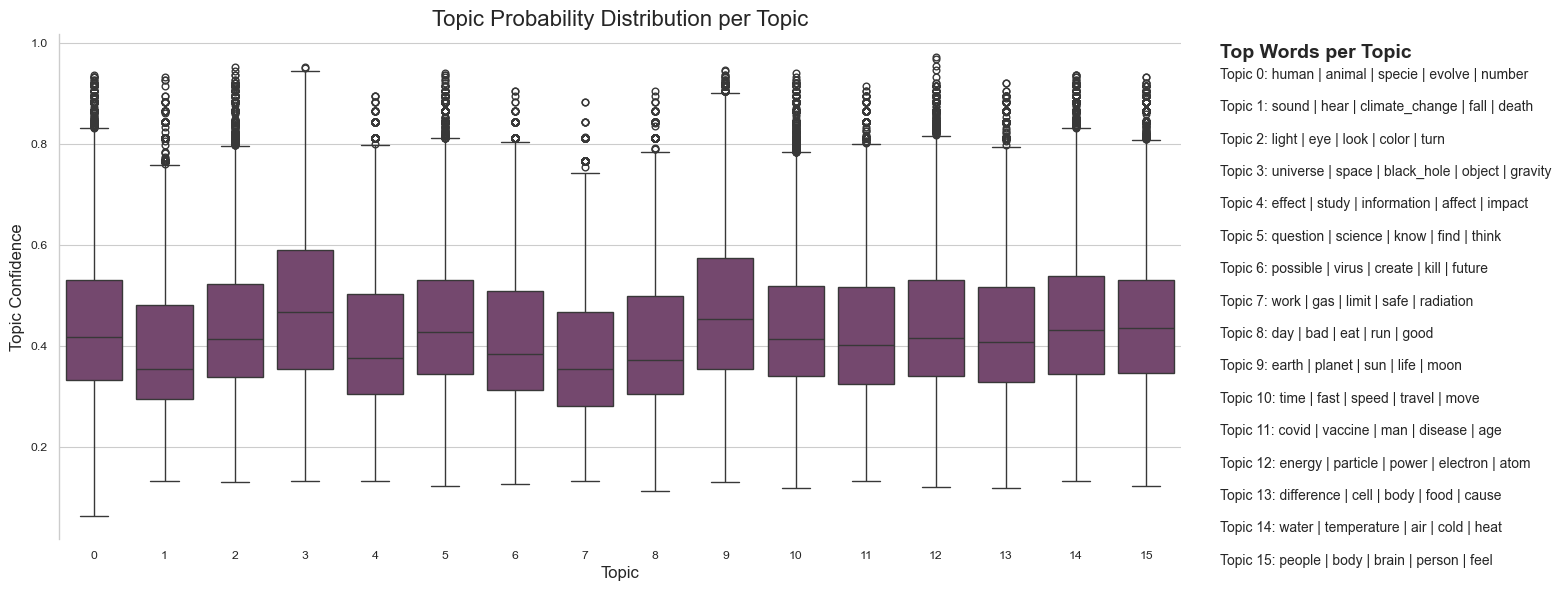

In [32]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="topic",
    y="topic_prob",
    color=plt.colormaps["tab20b"](16),
    ax=ax
)

# Titles and labels
ax.set_title("Topic Probability Distribution per Topic", fontsize=16)
ax.set_xlabel("Topic", fontsize=12)
ax.set_ylabel("Topic Confidence", fontsize=12)

# Despine plot
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# Build topic labels
words = vectorizer.get_feature_names_out()

topic_labels = {
    i: " | ".join(
        [words[j] for j in lda.components_[i].argsort()[-5:][::-1]]
    )
    for i in range(len(lda.components_))
}

# Build legend with top words
fig.text(
    1.02, 0.92,
    "Top Words per Topic",
    fontsize=14,
    fontweight="bold",
    va="top",
    ha="left"
)
legend_text = "\n\n".join(
    [f"Topic {i}: {topic_labels[i]}" for i in sorted(topic_labels)]
)
fig.text(
    1.02, 0.88,
    legend_text,
    fontsize=10,
    va="top",
    ha="left"
)

fig.subplots_adjust(right=0.7)

plt.tight_layout()
plt.savefig("viz/LDA_topic_confidence.png", dpi=300)
plt.show()